In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# File paths

ipsl_rsdt = r"D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//rsdt_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc"
ipsl_rsut = r"D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//rsut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc"
ipsl_rlut = r"D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//rlut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc"

cesm2_rsdt = r"D://Niharika Work//Climate_Project//CMIP6//CESM2_historical//rsdt_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc"
cesm2_rsut = r"D://Niharika Work//Climate_Project//CMIP6//CESM2_historical//rsut_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc"
cesm2_rlut = r"D://Niharika Work//Climate_Project//CMIP6//CESM2_historical//rlut_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc"

path_hist = "D://Niharika Work//Climate_Project//CMIP6//MPI-ESM1-2-LR_historical//"
# mpi_rsdt = r"data/MPI/rsdt.nc"
# mpi_rsut = r"data/MPI/rsut.nc"
# mpi_rlut = r"data/MPI/rlut.nc"

ceres_file = r"D://Niharika Work//Climate_Project//CERES_EBAF-TOA_Edition4.1-20260303_075023//CERES_EBAF-TOA_Edition4.1_200003-202203.nc"

In [3]:
# Load datasets

ipsl_rsdt_ds = xr.open_dataset(ipsl_rsdt)
ipsl_rsut_ds = xr.open_dataset(ipsl_rsut)
ipsl_rlut_ds = xr.open_dataset(ipsl_rlut)

cesm2_rsdt_ds = xr.open_dataset(cesm2_rsdt)
cesm2_rsut_ds = xr.open_dataset(cesm2_rsut)
cesm2_rlut_ds = xr.open_dataset(cesm2_rlut)

# mpi_rsdt_ds = xr.open_dataset(mpi_rsdt)
# mpi_rsut_ds = xr.open_dataset(mpi_rsut)
# mpi_rlut_ds = xr.open_dataset(mpi_rlut)

# MPI (combine multiple files)
mpi_rsdt_ds = xr.open_mfdataset(path_hist + "*rsdt*.nc", combine="by_coords")
mpi_rsut_ds = xr.open_mfdataset(path_hist + "*rsut*.nc", combine="by_coords")
mpi_rlut_ds = xr.open_mfdataset(path_hist + "*rlut*.nc", combine="by_coords")

ceres_ds = xr.open_dataset(ceres_file)

c:\Users\shubh\anaconda3\envs\climate_env\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'rsdt' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
c:\Users\shubh\anaconda3\envs\climate_env\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'rsut' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
c:\Users\shubh\anaconda3\envs\climate_env\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'rlut' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [4]:
ipsl_rsdt = ipsl_rsdt_ds["rsdt"]
ipsl_rsut = ipsl_rsut_ds["rsut"]
ipsl_rlut = ipsl_rlut_ds["rlut"]

cesm2_rsdt = cesm2_rsdt_ds["rsdt"]
cesm2_rsut = cesm2_rsut_ds["rsut"]
cesm2_rlut = cesm2_rlut_ds["rlut"]

mpi_rsdt = mpi_rsdt_ds["rsdt"]
mpi_rsut = mpi_rsut_ds["rsut"]
mpi_rlut = mpi_rlut_ds["rlut"]

ceres_net = ceres_ds["toa_net_all_mon"]

In [5]:
# Calculate Net TOA Radiation

ipsl_net = ipsl_rsdt - ipsl_rsut - ipsl_rlut
cesm2_net = cesm2_rsdt - cesm2_rsut - cesm2_rlut
mpi_net = mpi_rsdt - mpi_rsut - mpi_rlut

In [6]:
# print(cesm2_rsdt.mean().values)
# print(cesm2_rsut.mean().values)
# print(cesm2_rlut.mean().values)

In [7]:
# print(ipsl_rsdt.mean().values)
# print(ipsl_rsut.mean().values)
# print(ipsl_rlut.mean().values)

In [8]:
# print(mpi_rsdt.mean().values)
# print(mpi_rsut.mean().values)
# print(mpi_rlut.mean().values)

In [9]:
# Global mean weighting

weights = np.cos(np.deg2rad(ipsl_net.lat))


ipsl_global = ipsl_net.weighted(weights).mean(("lat","lon"))
cesm2_global = cesm2_net.weighted(weights).mean(("lat","lon"))
mpi_global = mpi_net.weighted(weights).mean(("lat","lon"))

ceres_global = ceres_net.weighted(weights).mean(("lat","lon"))

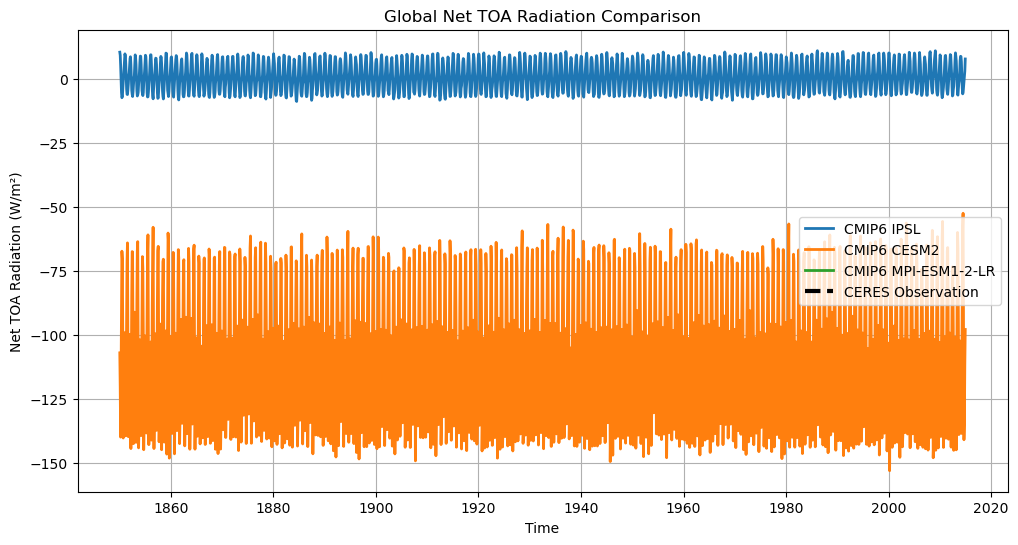

In [10]:
# Plot ALL MODELS + CERES

plt.figure(figsize=(12,6))

plt.plot(
    ipsl_global.time,
    ipsl_global,
    label="CMIP6 IPSL",
    linewidth=2
)

plt.plot(
    cesm2_global.time,
    cesm2_global,
    label="CMIP6 CESM2",
    linewidth=2
)

plt.plot(
    mpi_global.time,
    mpi_global,
    label="CMIP6 MPI-ESM1-2-LR",
    linewidth=2
)

plt.plot(
    ceres_global.time,
    ceres_global,
    label="CERES Observation",
    linewidth=3,
    color="black",
    linestyle="--"
)

plt.xlabel("Time")
plt.ylabel("Net TOA Radiation (W/m²)")
plt.title("Global Net TOA Radiation Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [11]:
ipsl_net = ipsl_rsdt - ipsl_rsut - ipsl_rlut
cesm2_net = cesm2_rsdt - cesm2_rsut - cesm2_rlut
mpi_net = mpi_rsdt - mpi_rsut - mpi_rlut

In [12]:
weights_ipsl = np.cos(np.deg2rad(ipsl_net.lat))
weights_cesm2 = np.cos(np.deg2rad(cesm2_net.lat))
weights_mpi = np.cos(np.deg2rad(mpi_net.lat))

ipsl_global = ipsl_net.weighted(weights_ipsl).mean(("lat","lon"))
cesm2_global = cesm2_net.weighted(weights_cesm2).mean(("lat","lon"))
mpi_global = mpi_net.weighted(weights_mpi).mean(("lat","lon"))

In [13]:
ipsl_global = ipsl_global.sel(time=slice("2001","2014"))
cesm2_global = cesm2_global.sel(time=slice("2001","2014"))
mpi_global = mpi_global.sel(time=slice("2001","2014"))

In [14]:
ceres_net = ceres_ds["toa_net_all_mon"]

In [15]:
weights_ceres = np.cos(np.deg2rad(ceres_net.lat))

In [16]:
ceres_global = ceres_net.weighted(weights_ceres).mean(("lat","lon"))

In [17]:
ceres_global = ceres_global.sel(time=slice("2001","2014"))

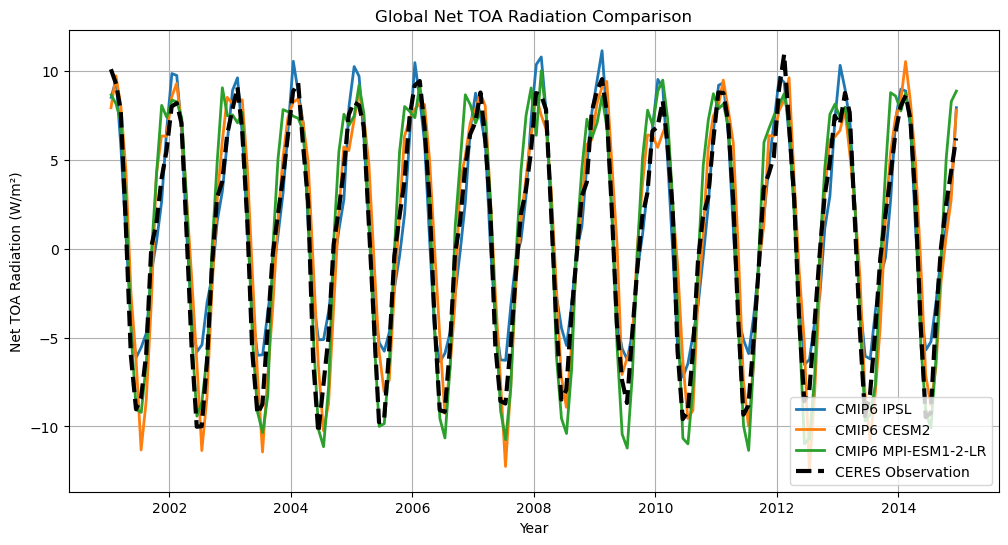

In [18]:
plt.figure(figsize=(12,6))

plt.plot(ipsl_global.time, ipsl_global, label="CMIP6 IPSL", linewidth=2)
plt.plot(cesm2_global.time, cesm2_global, label="CMIP6 CESM2", linewidth=2)
plt.plot(mpi_global.time, mpi_global, label="CMIP6 MPI-ESM1-2-LR", linewidth=2)

plt.plot(
    ceres_global.time,
    ceres_global,
    label="CERES Observation",
    color="black",
    linestyle="--",
    linewidth=3
)

plt.xlabel("Year")
plt.ylabel("Net TOA Radiation (W/m²)")
plt.title("Global Net TOA Radiation Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
ipsl_rsdt = ipsl_rsdt.sel(time=slice("2001","2014"))
ipsl_rsut = ipsl_rsut.sel(time=slice("2001","2014"))
ipsl_rlut = ipsl_rlut.sel(time=slice("2001","2014"))

cesm2_rsdt = cesm2_rsdt.sel(time=slice("2001","2014"))
cesm2_rsut = cesm2_rsut.sel(time=slice("2001","2014"))
cesm2_rlut = cesm2_rlut.sel(time=slice("2001","2014"))

mpi_rsdt = mpi_rsdt.sel(time=slice("2001","2014"))
mpi_rsut = mpi_rsut.sel(time=slice("2001","2014"))
mpi_rlut = mpi_rlut.sel(time=slice("2001","2014"))

ceres_net = ceres_net.sel(time=slice("2001","2014"))

In [20]:
sw_ipsl = ipsl_rsdt - ipsl_rsut
sw_cesm2 = cesm2_rsdt - cesm2_rsut
sw_mpi = mpi_rsdt - mpi_rsut

In [21]:
weights_ipsl = np.cos(np.deg2rad(sw_ipsl.lat))
weights_cesm2 = np.cos(np.deg2rad(sw_cesm2.lat))
weights_mpi = np.cos(np.deg2rad(sw_mpi.lat))

sw_ipsl_global = sw_ipsl.weighted(weights_ipsl).mean(("lat","lon"))
sw_cesm2_global = sw_cesm2.weighted(weights_cesm2).mean(("lat","lon"))
sw_mpi_global = sw_mpi.weighted(weights_mpi).mean(("lat","lon"))

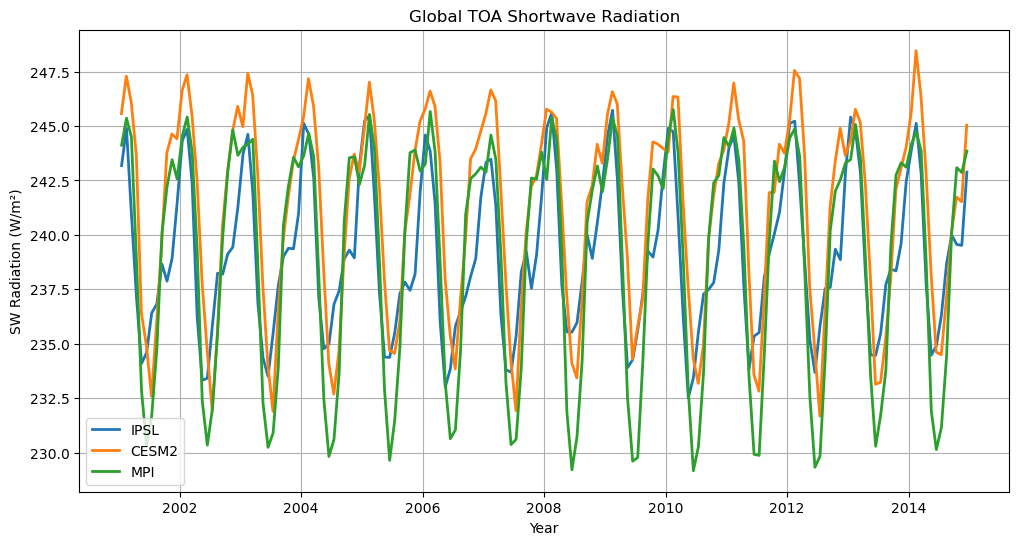

In [22]:
plt.figure(figsize=(12,6))

plt.plot(sw_ipsl_global.time, sw_ipsl_global, label="IPSL", linewidth=2)
plt.plot(sw_cesm2_global.time, sw_cesm2_global, label="CESM2", linewidth=2)
plt.plot(sw_mpi_global.time, sw_mpi_global, label="MPI", linewidth=2)

plt.xlabel("Year")
plt.ylabel("SW Radiation (W/m²)")
plt.title("Global TOA Shortwave Radiation")

plt.legend()
plt.grid(True)

plt.show()

In [23]:
lw_ipsl = -ipsl_rlut
lw_cesm2 = -cesm2_rlut
lw_mpi = -mpi_rlut

In [24]:
weights_ipsl = np.cos(np.deg2rad(lw_ipsl.lat))
weights_cesm2 = np.cos(np.deg2rad(lw_cesm2.lat))
weights_mpi = np.cos(np.deg2rad(lw_mpi.lat))

lw_ipsl_global = lw_ipsl.weighted(weights_ipsl).mean(("lat","lon"))
lw_cesm2_global = lw_cesm2.weighted(weights_cesm2).mean(("lat","lon"))
lw_mpi_global = lw_mpi.weighted(weights_mpi).mean(("lat","lon"))

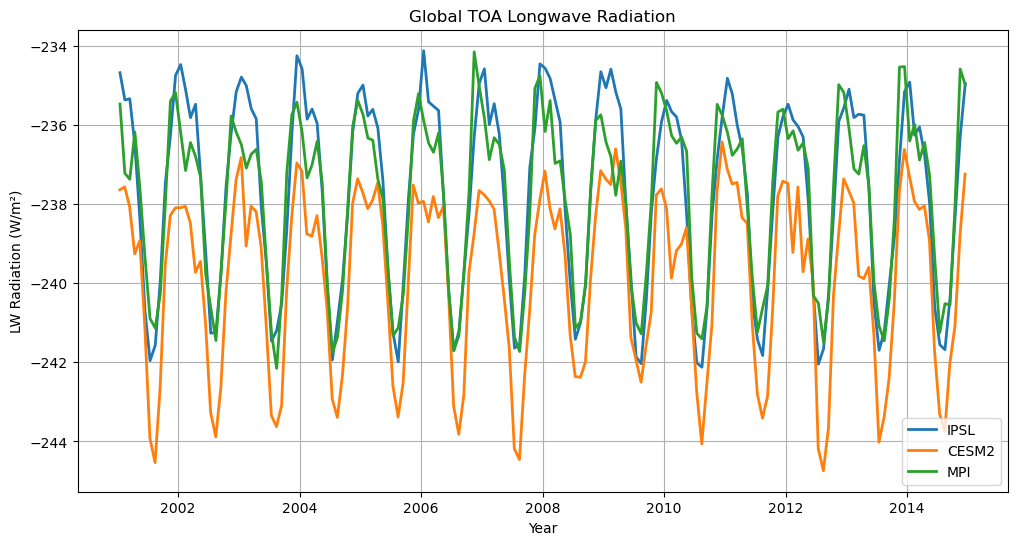

In [25]:
plt.figure(figsize=(12,6))

plt.plot(lw_ipsl_global.time, lw_ipsl_global, label="IPSL", linewidth=2)
plt.plot(lw_cesm2_global.time, lw_cesm2_global, label="CESM2", linewidth=2)
plt.plot(lw_mpi_global.time, lw_mpi_global, label="MPI", linewidth=2)

plt.xlabel("Year")
plt.ylabel("LW Radiation (W/m²)")
plt.title("Global TOA Longwave Radiation")

plt.legend()
plt.grid(True)

plt.show()

In [26]:
ceres_sw = ceres_ds["toa_sw_all_mon"].sel(time=slice("2001","2014"))
ceres_lw = ceres_ds["toa_lw_all_mon"].sel(time=slice("2001","2014"))

In [27]:
weights_ceres = np.cos(np.deg2rad(ceres_sw.lat))

ceres_sw_global = ceres_sw.weighted(weights_ceres).mean(("lat","lon"))
ceres_lw_global = ceres_lw.weighted(weights_ceres).mean(("lat","lon"))

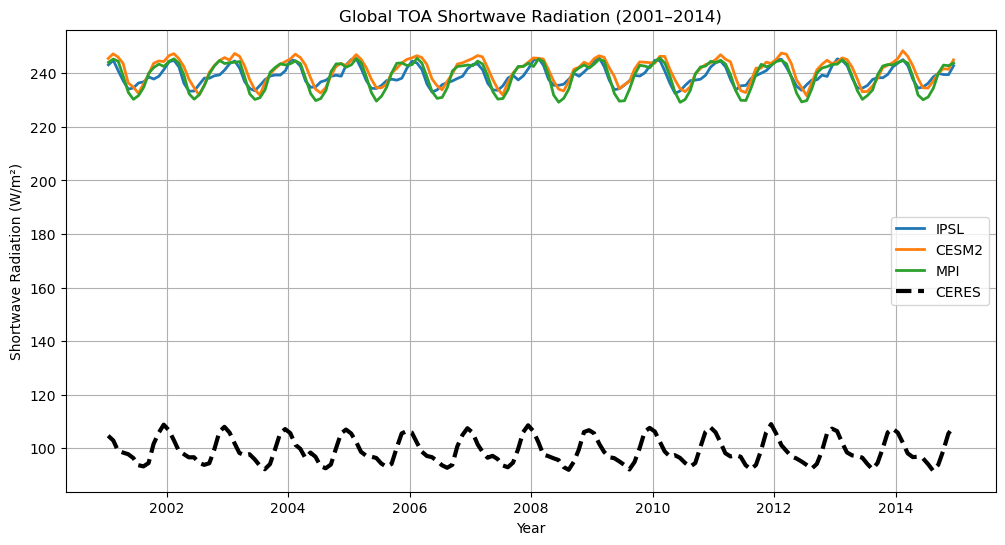

In [28]:
plt.figure(figsize=(12,6))

plt.plot(sw_ipsl_global.time, sw_ipsl_global, label="IPSL", linewidth=2)
plt.plot(sw_cesm2_global.time, sw_cesm2_global, label="CESM2", linewidth=2)
plt.plot(sw_mpi_global.time, sw_mpi_global, label="MPI", linewidth=2)

plt.plot(
    ceres_sw_global.time,
    ceres_sw_global,
    label="CERES",
    linestyle="--",
    color="black",
    linewidth=3
)

plt.xlabel("Year")
plt.ylabel("Shortwave Radiation (W/m²)")
plt.title("Global TOA Shortwave Radiation (2001–2014)")

plt.legend()
plt.grid(True)

plt.show()

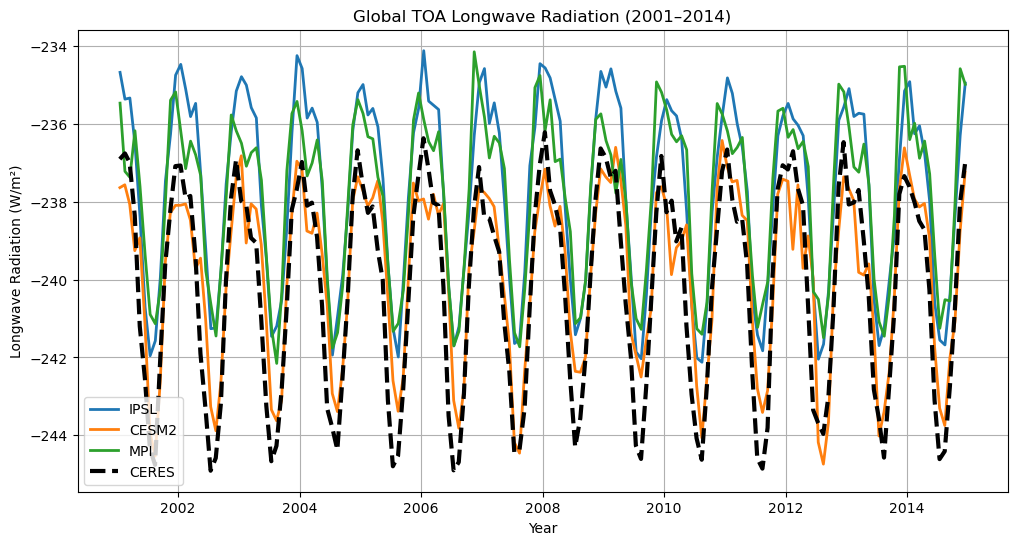

In [29]:
plt.figure(figsize=(12,6))

plt.plot(lw_ipsl_global.time, lw_ipsl_global, label="IPSL", linewidth=2)
plt.plot(lw_cesm2_global.time, lw_cesm2_global, label="CESM2", linewidth=2)
plt.plot(lw_mpi_global.time, lw_mpi_global, label="MPI", linewidth=2)

plt.plot(
    ceres_lw_global.time,
    -ceres_lw_global,
    label="CERES",
    linestyle="--",
    color="black",
    linewidth=3
)

plt.xlabel("Year")
plt.ylabel("Longwave Radiation (W/m²)")
plt.title("Global TOA Longwave Radiation (2001–2014)")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
ceres_sw_down = ceres_ds["solar_mon"]
ceres_sw_up = ceres_ds["toa_sw_all_mon"]

ceres_sw_net = ceres_sw_down - ceres_sw_up

In [31]:
weights_ceres = np.cos(np.deg2rad(ceres_sw_net.lat))

ceres_sw_global = ceres_sw_net.weighted(weights_ceres).mean(("lat","lon"))

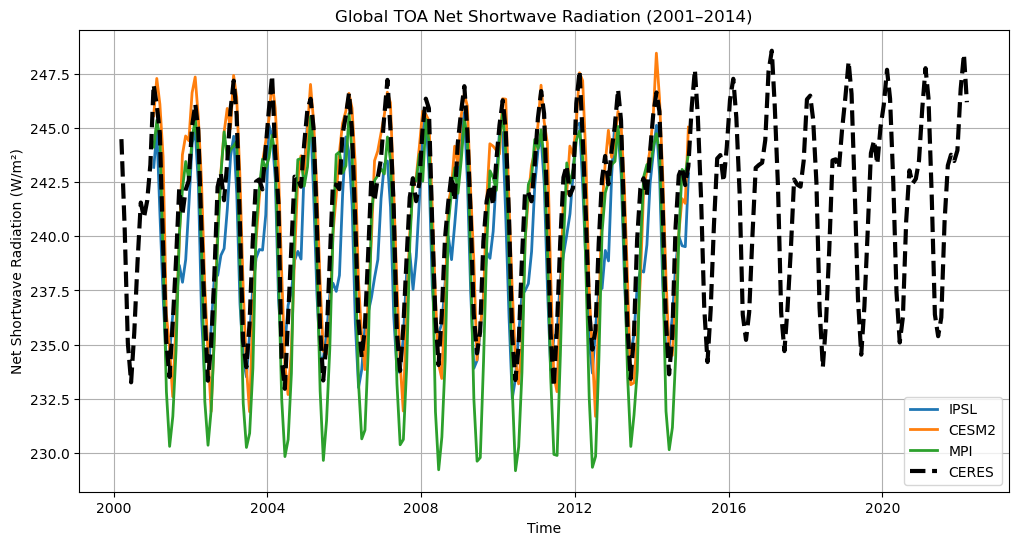

In [32]:
plt.figure(figsize=(12,6))

plt.plot(sw_ipsl_global.time, sw_ipsl_global, label="IPSL", linewidth=2)
plt.plot(sw_cesm2_global.time, sw_cesm2_global, label="CESM2", linewidth=2)
plt.plot(sw_mpi_global.time, sw_mpi_global, label="MPI", linewidth=2)

plt.plot(
    ceres_sw_global.time,
    ceres_sw_global,
    label="CERES",
    linestyle="--",
    color="black",
    linewidth=3
)

plt.xlabel("Time")
plt.ylabel("Net Shortwave Radiation (W/m²)")
plt.title("Global TOA Net Shortwave Radiation (2001–2014)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,1, figsize=(12,12), sharex=True)


# =========================
# Panel 1 : NET TOA
# =========================

ax[0].plot(ipsl_global.time, ipsl_global, label="IPSL", linewidth=2)
ax[0].plot(cesm2_global.time, cesm2_global, label="CESM2", linewidth=2)
ax[0].plot(mpi_global.time, mpi_global, label="MPI", linewidth=2)

ax[0].plot(
    ceres_global.time,
    ceres_global,
    linestyle="--",
    color="black",
    linewidth=3,
    label="CERES"
)

ax[0].set_title("Global Net TOA Radiation (2001–2014)")
ax[0].set_ylabel("W/m²")
ax[0].grid(True)
ax[0].legend()


# =========================
# Panel 2 : SHORTWAVE
# =========================

ax[1].plot(sw_ipsl_global.time, sw_ipsl_global, linewidth=2)
ax[1].plot(sw_cesm2_global.time, sw_cesm2_global, linewidth=2)
ax[1].plot(sw_mpi_global.time, sw_mpi_global, linewidth=2)

ax[1].plot(
    ceres_sw_global.time,
    ceres_sw_global,
    linestyle="--",
    color="black",
    linewidth=3
)

ax[1].set_title("Global TOA Shortwave Radiation (2001–2014)")
ax[1].set_ylabel("W/m²")
ax[1].grid(True)


# =========================
# Panel 3 : LONGWAVE
# =========================

ax[2].plot(lw_ipsl_global.time, lw_ipsl_global, linewidth=2)
ax[2].plot(lw_cesm2_global.time, lw_cesm2_global, linewidth=2)
ax[2].plot(lw_mpi_global.time, lw_mpi_global, linewidth=2)

ax[2].plot(
    ceres_lw_global.time,
    -ceres_lw_global,
    linestyle="--",
    color="black",
    linewidth=3
)

ax[2].set_title("Global TOA Longwave Radiation (2001–2014)")
ax[2].set_ylabel("W/m²")
ax[2].set_xlabel("Year")
ax[2].grid(True)


plt.tight_layout()
plt.show()